In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("Coffee Shop Sales.csv")

In [28]:
df.head(5)

,transaction id,transaction date,transaction time,transaction qty,store id,store location,product id,unit price,product category,product type,product detail
0,1,01/01/23,7:06:11 AM,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01/01/23,7:08:56 AM,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01/01/23,7:14:04 AM,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01/01/23,7:20:24 AM,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01/01/23,7:22:41 AM,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [29]:
df["total_sales"] = df["transaction qty"] * df["unit price"]

In [30]:
df.describe()

,transaction id,transaction qty,store id,product id,unit price,total_sales
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219,4.686367
std,43153.600016,0.542509,2.074241,17.930020,2.658723,4.227099
min,1.000000,1.000000,3.000000,1.000000,0.800000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000,3.000000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000,3.750000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000,6.000000
max,149456.000000,8.000000,8.000000,87.000000,45.000000,360.000000


In [31]:
df.dtypes

,0
transaction id,int64
transaction date,object
transaction time,object
transaction qty,int64
store id,int64
store location,object
product id,int64
unit price,float64
product category,object
product type,object


In [32]:
df.nunique()

,0
transaction id,149116
transaction date,181
transaction time,25762
transaction qty,6
store id,3
store location,3
product id,80
unit price,41
product category,9
product type,29


In [33]:
df.isnull().sum()

,0
transaction id,0
transaction date,0
transaction time,0
transaction qty,0
store id,0
store location,0
product id,0
unit price,0
product category,0
product type,0


In [34]:
df.duplicated().sum()

0

In [35]:
# Convert the 'transaction_date' column to datetime objects
df['transaction date'] = pd.to_datetime(df['transaction date'])

# Buat kolom nama hari dalam seminggu
df["day_of_week"] = df["transaction date"].dt.day_name()
# Convert the 'transaction_date' column to datetime objects
df['transaction_date'] = pd.to_datetime(df['transaction date'])

# Group by transaction id and sum the total uniq
daily_sales = df.groupby('day_of_week')['transaction qty'].sum().sort_values (ascending=False)

print(daily_sales)

day_of_week
Monday       31231
Friday       31207
Thursday     31162
Wednesday    30625
Tuesday      30449
Sunday       30182
Saturday     29614
Name: transaction qty, dtype: int64


<ipython-input-35-a8f3ab13b29e>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction date'] = pd.to_datetime(df['transaction date'])


In [36]:
df.head()

,transaction id,transaction date,transaction time,transaction qty,store id,store location,product id,unit price,product category,product type,product detail,total_sales,day_of_week,transaction_date
0,1,2023-01-01,7:06:11 AM,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,Sunday,2023-01-01
1,2,2023-01-01,7:08:56 AM,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,Sunday,2023-01-01
2,3,2023-01-01,7:14:04 AM,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,Sunday,2023-01-01
3,4,2023-01-01,7:20:24 AM,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,Sunday,2023-01-01
4,5,2023-01-01,7:22:41 AM,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,Sunday,2023-01-01


<ipython-input-37-029fdbeb68b5>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction time'] = pd.to_datetime(df['transaction time'])


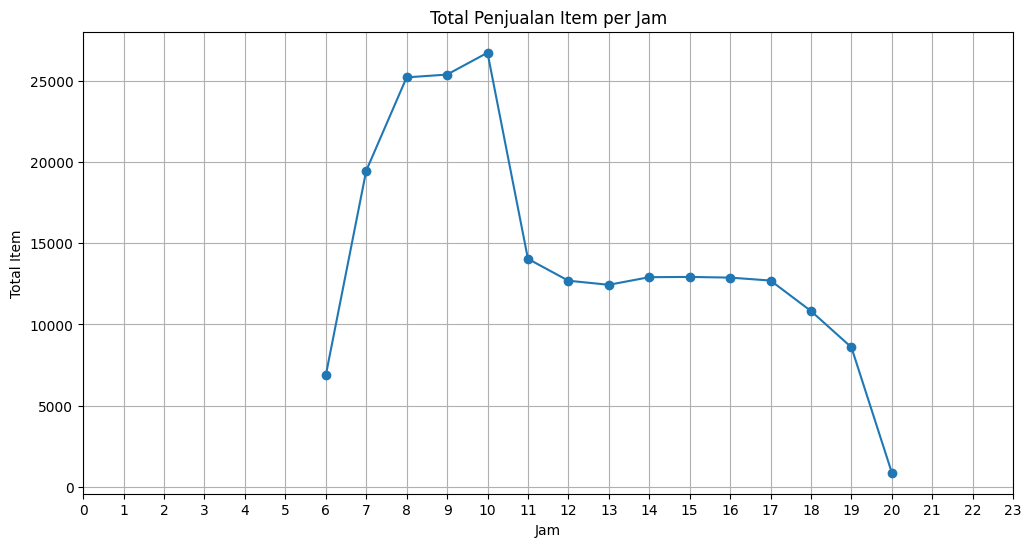

In [37]:
# Convert 'transaction time' to datetime objects before using .dt accessor
df['transaction time'] = pd.to_datetime(df['transaction time'])

# Group by hour and sum the transaction quantity
df["hour"] = df["transaction time"].dt.hour
hourly_sales = df.groupby("hour")["transaction qty"].sum()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(hourly_sales.index, hourly_sales.values, marker='o')
plt.title('Total Penjualan Item per Jam')
plt.xlabel('Jam')
plt.ylabel('Total Item')
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [38]:
#top categories
top_categories = df.groupby("product category")["transaction qty"].sum().sort_values(ascending=False)
print(top_categories)

product category
Coffee                89250
Tea                   69737
Bakery                23214
Drinking Chocolate    17457
Flavours              10511
Coffee beans           1828
Loose Tea              1210
Branded                 776
Packaged Chocolate      487
Name: transaction qty, dtype: int64


In [40]:
#Top and Bottom product
top_product = df.groupby('product type')['transaction qty'].sum().sort_values(ascending=False)
print(top_product.head(5))
bottom_product = df.groupby('product type')['transaction qty'].sum().sort_values(ascending=True)
print(bottom_product.head(5))

product type
Brewed Chai tea          26250
Gourmet brewed coffee    25973
Barista Espresso         24943
Brewed Black tea         17462
Hot chocolate            17457
Name: transaction qty, dtype: int64
product type
Green beans          134
Green tea            159
House blend Beans    183
Organic Chocolate    221
Clothing             221
Name: transaction qty, dtype: int64


In [41]:
# Calculate total revenue for each product
product_revenue = df.groupby('product type')['total_sales'].sum().sort_values(ascending=False)

# Find the most profitable product
print(product_revenue.head(5))


product type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Name: total_sales, dtype: float64


In [42]:
# perbandingan revenue, product type dan transaction qty
revenue = df.groupby("product type")[["transaction qty", "total_sales"]].sum().reset_index().sort_values(by="total_sales", ascending=False)
print(revenue.head(5))


             product type  transaction qty  total_sales
0        Barista Espresso            24943     91406.20
4         Brewed Chai tea            26250     77081.95
17          Hot chocolate            17457     72416.00
13  Gourmet brewed coffee            25973     70034.60
3        Brewed Black tea            17462     47932.00


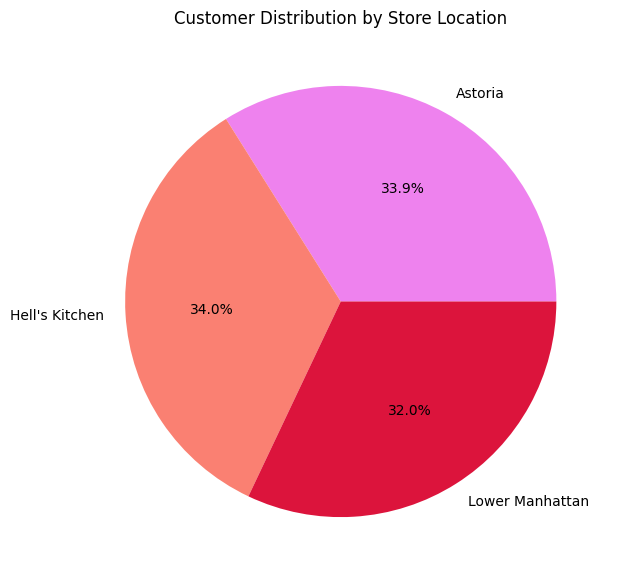

In [43]:
#customer distribution by store location
grouped_location = df.groupby('store location')['transaction id'].nunique()
grouped_location.plot(kind='pie', autopct='%1.1f%%', colors=['violet','salmon','crimson'], figsize=(7, 7))
plt.title('Customer Distribution by Store Location')
plt.ylabel('')
plt.show()

In [45]:
#customer distribution by store location
grouped_location = df.groupby('store location')['transaction id'].nunique().sort_values(ascending=False)
print(grouped_location)

store location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: transaction id, dtype: int64
